# Template for Practical work on the Conversion of sampling frequency and STFT


*From R. Badeau and G. Richard (with help from P. Vernhet), MAJ:2020*

**python version : 3.6**

In [16]:
import os, sys, wave, struct

import numpy as np
import pyaudio
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from math import ceil
from scipy.io.wavfile import write

## Functions

In [17]:
def load_sound(file):
    return wave.open(file, 'rb')


def play_sound(file, chunk = 1024):
    """
    Script from PyAudio doc
    """
    wf = load_sound(file)
    p = pyaudio.PyAudio()
    stream = p.open(format=p.get_format_from_width(wf.getsampwidth()),
                    channels=wf.getnchannels(),
                    rate=wf.getframerate(),
                    output=True)
    data = wf.readframes(chunk)

    while data:
        stream.write(data)
        data = wf.readframes(chunk )

    stream.stop_stream()
    stream.close()
    p.terminate()
    
    
def plot_sound(data, times, name='default_name', save=False):
    plt.figure(figsize=(30, 4))
    plt.fill_between(times, data)
    plt.xlim(times[0], times[-1])
    plt.xlabel('time (s)')
    plt.ylabel('amplitude')
    if save:
        plt.savefig(name+'.png', dpi=100)
    plt.show()

## Reading and playing .wav file

Choose the name of sound for the rest of the notebook. Sounds are assumed to be set in a folder named 'sons_mutltipitch' (same directory as notebook).

In [18]:
data_path = os.getcwd()
filename = 'caravan_48khz.wav'
sound = os.path.join(data_path, filename) 

### **Using wave**

In [19]:
wavefile = load_sound(sound)
print(wavefile.getparams())

_wave_params(nchannels=1, sampwidth=2, framerate=48000, nframes=805733, comptype='NONE', compname='not compressed')


In [20]:
play = False
if play :
    play_sound(sound) 

In [21]:
Fs = int(wavefile.getframerate())
num_samples = int(wavefile.getnframes())
data = wavefile.readframes(num_samples)
data = struct.unpack('{n}h'.format(n=num_samples), data)
x = np.array(data)

In [22]:
timestep = 1/float(Fs)
times = np.arange(len(x))*timestep

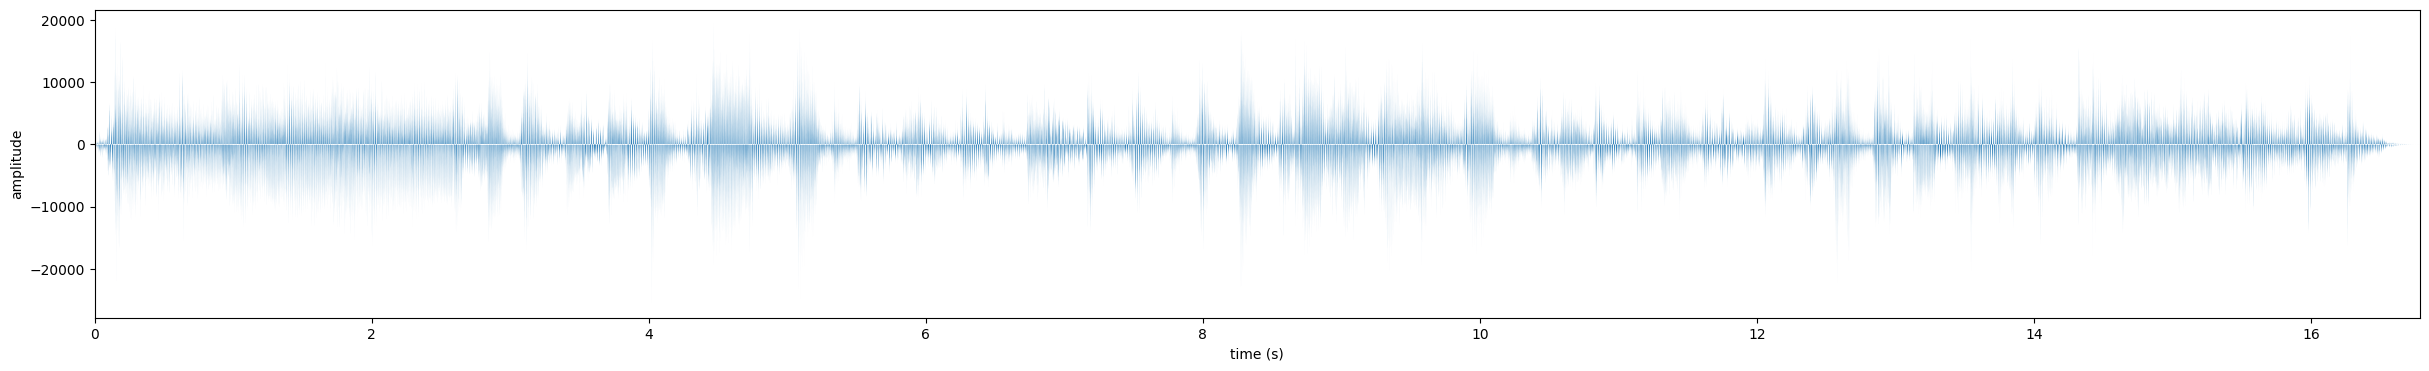

In [23]:
plot_sound(x, times)

In [24]:
write('new_caravan.wav', Fs, np.array(x, dtype=np.int16)) # to write a new wave file

## Signal analysis with the STFT

In [25]:
N = x.shape[0] # % longueur du signal
Nw = 512
w = np.hanning(Nw) # définition de la fenetre d'analyse
ws = w.copy; # définition de la fenêtre de synthèse
R = Nw/4 # incrément sur les temps d'analyse, appelé hop size, t_a=uR
M = 512 # ordre de la tfd
L = M/2+1
affich = 1 ; # pour affichage du spectrogramme, 0 pour
             # pour faire analyse/modif/synthèse sans affichage
             # note: cf. spectrogram sous Matlab
Nt = np.rint((N - Nw) / R) # calcul du nombre de tfd à calculer
Nt = Nt.astype(int)
y = np.zeros((N,1)) # signal de synthèse

if affich:
    Xtilde = np.zeros((M,Nt),dtype=complex)

In [26]:
for u in np.arange(0,Nt).reshape(-1): # boucle sur les trames
    deb = u * R + 1 # début de trame
    fin = deb + Nw # fin de trame
    tx = np.multiply(x[np.arange(deb.astype(int),fin.astype(int))],w) # calcul de la trame 
    X = np.fft.fft(tx,M) # tfd à l'instant b
    if affich:
        Xtilde[:,u] = X
    # opérations de transformation (sur la partie \nu > 0)
    # ....
    Y = X.copy
    # fin des opérations de transformation
    # resynthèse
    # overlap add

def extents(f):
  delta = f[1] - f[0]
  return [f[0] - delta/2, f[-1] + delta/2]

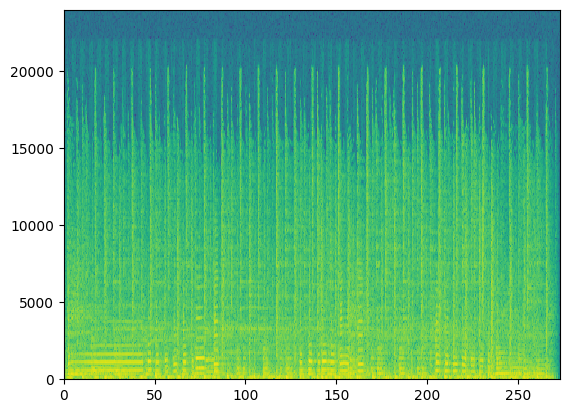

In [27]:
if affich:
    plt.imshow(20*np.log10(np.abs(Xtilde[np.arange(0,int(L)),:])), aspect='auto',interpolation='none',
               origin='lower', extent=[0, Nt * R / Fs + Nw / 2, 0, Fs/2])
    

## Overlap-add reconstruction

In [28]:
def ola(w = None,hop = None,Nb = 10): 
# function output = ola(w,hop,Nb)
# realise l'addition-recouvrement de la fenetre w,
# avec un décalage hop et un nombre Nb de fenetres.
# par defaut Nb = 10;
    
    w = w[:, np.newaxis]
    N = len(w)
    output = np.zeros(((Nb - 1) * hop + N,1)) # réserve l'espace memoire
    
    for k in np.arange(0,Nb).reshape(-1):
        deb = k* hop
        fin = deb + N
        output[np.arange(deb,fin)] = output[np.arange(deb,fin)] + w # OLA
    
    return output

## 1. Conversion of sampling rate

Q1: To convert the sampling rate from $F_s = 48 \text{ kHz}$ to $F_s' = 32 \text{ kHz}$, the rational conversion factor is $\frac{32}{48} = \frac{2}{3}$.

Thus, the interpolation factor is $L=2$ and the decimation factor is $M=3$.The digital processing chain consists of:
- Upsampling by $L=2$ (inserting $L-1$ zeros between each sample).
- Low-pass filtering with the filter $H(z)$.
- Downsampling by $M=3$ 

The characteristics of the ideal low-pass filter $H(z)$ are:
- Cut-off frequency: $\nu_c = \min\left(\frac{1}{2L}, \frac{1}{2M}\right) = \min\left(\frac{1}{4}, \frac{1}{6}\right) = \frac{1}{6}$ (normalized frequency).
- Gain: $L = 2$ in the pass-band to compensate for the energy loss caused by the zero-insertion during upsampling.

Q2 :


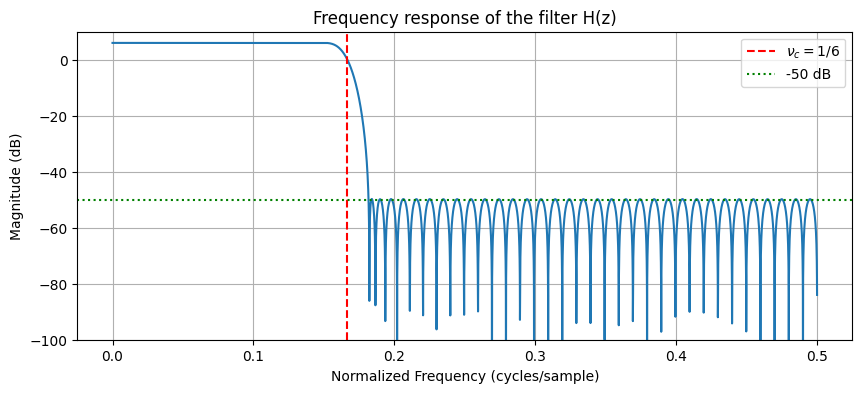

In [ ]:
from scipy.signal import remez, freqz

L = 2
M = 3
# Small transition band
nu_c = 1/6 - 0.015
nu_a = 1/6 + 0.015

order = 100  
h = remez(order, [0, nu_c, nu_a, 0.5], [1, 0], fs=1.0)

# gain L
h = h * L

# Plot
w, H = freqz(h, worN=8000)
plt.figure(figsize=(10, 4))
plt.plot(w / (2 * np.pi), 20 * np.log10(np.abs(H) + 1e-12))
plt.title('Frequency response of the filter H(z)')
plt.xlabel('Normalized Frequency (cycles/sample)')
plt.ylabel('Magnitude (dB)')
plt.axvline(1/6, color='r', linestyle='--', label=r'$\nu_c = 1/6$')
plt.axhline(-50, color='g', linestyle=':', label='-50 dB')
plt.ylim(-100, 10)
plt.legend()
plt.grid(True)
plt.show()

Q3 : 

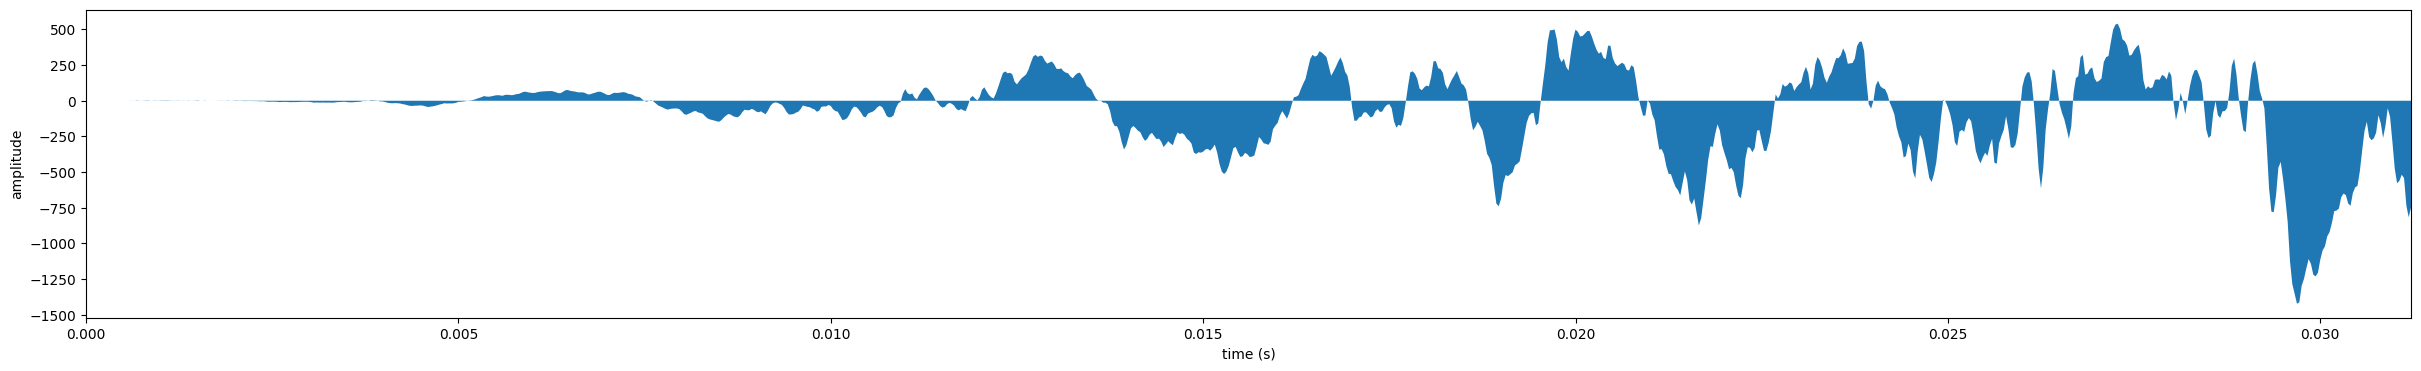

In [ ]:
from scipy.signal import lfilter
import time

# Upsampling by L=2
x_up = np.zeros(len(x) * L)
x_up[::L] = x

# Filtering
start_time_simple = time.time()
x_filt = lfilter(h, 1.0, x_up)

# Downsampling by M=3
y_simple = x_filt[::M]
end_time_simple = time.time()

time_simple = end_time_simple - start_time_simple

Fs_new = Fs * L / M
times_new = np.arange(len(y_simple)) / Fs_new

plot_sound(y_simple[:1000], times_new[:1000], name='Converted_Signal_Simple')

Q4 :
Figure 1 shows the Noble Identities, which explain how filtering can be rearranged with upsampling and downsampling to make the processing more efficient.

By moving the downsampling before the filter (Type I polyphase) and the upsampling after the filter (Type II polyphase), the convolution is performed at the lowest possible sampling rate. This avoids computing samples that would be discarded by the decimator or multiplied by zeros from the interpolator.

Q5 :

In [ ]:
from scipy.signal import upfirdn

start_time_poly = time.time()
y_polyphase = upfirdn(h, x, up=L, down=M)
end_time_poly = time.time()

time_poly = end_time_poly - start_time_poly

Q6 : 

In [32]:
print(f"Running time (Naive/Simple): {time_simple:.4f} seconds")
print(f"Running time (Polyphase): {time_poly:.4f} seconds")

# Truncate to the same length to compare error due to edge effects handling in lfilter vs upfirdn
min_len = min(len(y_simple), len(y_polyphase))
mse = np.mean((y_simple[:min_len] - y_polyphase[:min_len])**2)
print(f"Mean Squared Error between both methods: {mse:.2e}")

Running time (Naive/Simple): 0.0659 seconds
Running time (Polyphase): 0.0276 seconds
Mean Squared Error between both methods: 6.82e-25


## 2. STFT analysis

Q1 :

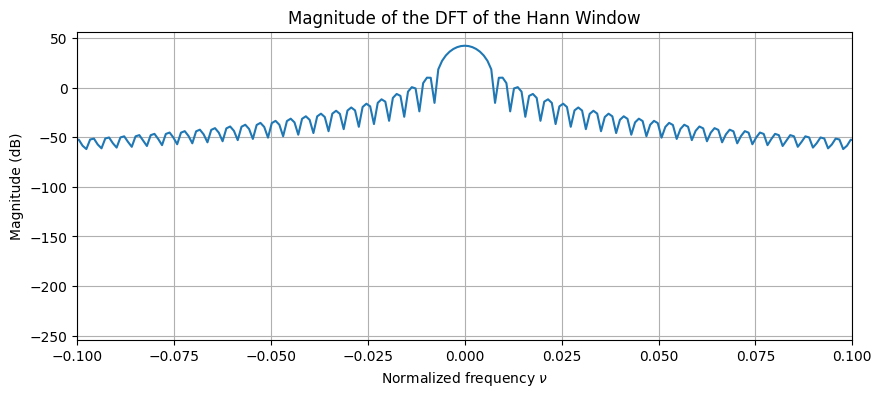

In [33]:
from scipy.signal.windows import hann
from scipy.fft import fft, fftshift

Nw = 256
M_dft = 1024 # Zero-padding for smoother spectrum

w = hann(Nw, sym=True)
W = fft(w, n=M_dft)
W_shifted = fftshift(W)
freqs = np.fft.fftshift(np.fft.fftfreq(M_dft))

plt.figure(figsize=(10, 4))
plt.plot(freqs, 20 * np.log10(np.abs(W_shifted) + 1e-12))
plt.title('Magnitude of the DFT of the Hann Window')
plt.xlabel('Normalized frequency $\\nu$')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.xlim(-0.1, 0.1)
plt.show()

The main lobe width of a Hann window is given by $\Delta \nu = \frac{4}{N_w}$ in normalized frequency. If plotted as a function of the physical frequency $f$, the width is $\frac{4 F_s}{N_w}$.

Q2 :

The discrete-time STFT under the "low-pass convention" is:$$W_x(\lambda, b) = \sum_{n \in \mathbb{Z}} x(n) w(n-b) e^{-j 2\pi \lambda n}$$If we view $\lambda$ as fixed and $b$ as the time index, this equation resembles a convolution. 

Let $h(n) = w(-n) e^{-j 2\pi \lambda (-n)}$, then the STFT can be written as the convolution between the signal $x$ and the filter $h$.

Since the window $w(n)$ is a low-pass filter envelope, multiplying it by the complex exponential shifts its spectrum to be centered around the frequency $\lambda$.

Therefore, for a given $\lambda$, the STFT acts as a band-pass filter centered at $\lambda$.

Because $w(n)$ is real and symmetric, the underlying prototype window acts as a linear phase FIR filter. If its length is odd, it is a Type 1 filter (symmetry, integer delay). If its length is even, it is a Type 2 filter (symmetry, half-sample delay).

Q3 : The alternative STFT definition is:
$$\tilde{X}(\lambda, b) = \sum_{n \in \mathbb{Z}} x(n+b) w(n) e^{-j 2\pi \lambda n}$$
This is called the "band-pass convention" because if we expand the formula by letting $m = n+b$ (so $n = m-b$), we get:$$\tilde{X}(\lambda, b) = \sum_{m \in \mathbb{Z}} x(m) w(m-b) e^{-j 2\pi \lambda (m-b)} = e^{j 2\pi \lambda b} \sum_{m \in \mathbb{Z}} x(m) w(m-b) e^{-j 2\pi \lambda m}$$Thus, $\tilde{X}(\lambda, b) = e^{j 2\pi \lambda b} W_x(\lambda, b)$.The modulation term $e^{j 2\pi \lambda b}$ essentially shifts the baseband STFT signal back to its original frequency band $\lambda$. While $W_x$ demodulates the frequency bin down to baseband (hence "low-pass convention"), $\tilde{X}$ retains the local oscillatory carrier of the band (hence "band-pass convention").